# ANÁLISIS EXPLORATORIO DE DATOS

In [279]:
import kagglehub
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

## Definición del problema
> - Recopilar los datos de ventas para visualizar compradores en potencia y los productos que mejor se venden.

## Recopilación de datos

In [280]:
# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [281]:
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_order_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")
df_sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
df_product_category_name_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

In [282]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [283]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [284]:
# Unir Órdenes con Clientes
df_master = pd.merge(df_orders, df_customers, on="customer_id", how="left")

In [285]:
df_order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [286]:
# Unir con los Ítems 
df_master = pd.merge(df_master, df_order_items, on="order_id", how="left")

In [287]:
df_products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [288]:
# Unir con Productos
df_master = pd.merge(df_master, df_products, on="product_id", how="left")

# Traducir las categorías (Para que sea legible)
df_master = pd.merge(df_master, df_product_category_name_translation, on="product_category_name", how="left")

In [289]:
df_order_payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [290]:
# df_master = pd.merge(df_master, df_order_payments, on="order_id", how="left")

In [291]:
df_master.head(15)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,...,27.36,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,auto
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,...,16.05,NaN,NaN,NaN,NaN,600.0,35.0,35.0,15.0,NaN
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,...,15.17,automotivo,59.0,956.0,1.0,50.0,16.0,16.0,17.0,auto
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,39382392765b6dc74812866ee5ee92a7,99655,...,16.05,moveis_decoracao,41.0,432.0,2.0,300.0,35.0,35.0,15.0,furniture_decor
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,299905e3934e9e181bfb2e164dd4b4f8,18075,...,19.77,moveis_escritorio,45.0,527.0,1.0,9750.0,42.0,41.0,42.0,office_furniture


## Análisis descriptivo

In [292]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  113425 non-null  str    
 8   customer_unique_id             113425 non-null  str    
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  str    
 11  customer_state                 113425 non-null  str    
 12  order_item_id                  112650 non

In [293]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  793
product_cate

## Limpieza de datos

In [294]:
df_master.duplicated().sum()

np.int64(0)

In [295]:
df_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='str')

In [296]:
# df_master.drop(["order_status", "order_approved_at", "order_delivered_carrier_date", "order_estimated_delivery_date", "customer_zip_code_prefix", "customer_city",
#                 "customer_state", "seller_id", "shipping_limit_date", "freight_value", "product_category_name", "product_name_lenght", 
#                 "product_description_lenght", "product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm",
#                 "product_width_cm", "payment_sequential", "payment_type", "payment_installments", "order_delivered_customer_date", "payment_value", "price"], axis=1, inplace=True)

In [297]:
df_master.drop(["order_status", "order_approved_at", "order_delivered_carrier_date", "order_estimated_delivery_date", "customer_zip_code_prefix", "customer_city",
                "customer_state", "seller_id", "shipping_limit_date", "freight_value", "product_category_name", "product_name_lenght", 
                "product_description_lenght", "product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm",
                "product_width_cm", "order_delivered_customer_date", "price"], axis=1, inplace=True)

In [298]:
df_master.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'customer_unique_id', 'order_item_id', 'product_id',
       'product_category_name_english'],
      dtype='str')

In [299]:
df_master

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_id,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,87285b34884572647811a353c7ac498a,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,1.0,595fac2a385ac33a80bd5114aec74eb8,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,1.0,aa4383b373c6aca5d8797843e5594415,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,1.0,65266b2da20d04dbe00c5c2d3bb7859e,stationery
...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,da62f9e57a76d978d02ab5362c509660,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,baby
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,737520a9aad80b3fbbdad19b66b37b30,1.0,b80910977a37536adeddd63663f916ad,home_appliances_2
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories


## Análisis de las variables

### Análisis univariante de variables categóricas.

In [300]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_purchase_timestamp       113425 non-null  str    
 3   customer_unique_id             113425 non-null  str    
 4   order_item_id                  112650 non-null  float64
 5   product_id                     112650 non-null  str    
 6   product_category_name_english  111023 non-null  str    
dtypes: float64(1), str(6)
memory usage: 6.1 MB


In [ ]:
df_master["order_id"].value_counts()

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
428a2f660dc84138d969ccd69a0ab6d5    15
9ef13efd6949e4573a18964dd1bbe7f5    15
                                    ..
880675dff2150932f1601e1c07eadeeb     1
9c5dedf39a927c1b2549525ed64a053c     1
63943bddc261676b46f01ca7ac2f7bd8     1
83c1379a015df1e13d02aae0204711ab     1
66dea50a8b16d9b4dee7af250b4be1a5     1
Name: count, Length: 99441, dtype: int64

In [312]:
df_master[df_master["order_id"] == "8272b63d03f5f79c56e9e4120aec44ef"].head(20)

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_id,product_category_name_english
101222,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,1.0,270516a3f41dc035aa87d220228f844c,health_beauty
101223,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,2.0,05b515fdc76e888aada3c6d66c201dff,health_beauty
101224,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,3.0,05b515fdc76e888aada3c6d66c201dff,health_beauty
101225,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,4.0,05b515fdc76e888aada3c6d66c201dff,health_beauty
101226,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,5.0,05b515fdc76e888aada3c6d66c201dff,health_beauty
101227,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,6.0,05b515fdc76e888aada3c6d66c201dff,health_beauty
101228,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,7.0,05b515fdc76e888aada3c6d66c201dff,health_beauty
101229,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,8.0,05b515fdc76e888aada3c6d66c201dff,health_beauty
101230,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,9.0,05b515fdc76e888aada3c6d66c201dff,health_beauty
101231,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,10.0,05b515fdc76e888aada3c6d66c201dff,health_beauty


In [315]:
df_master[df_master["order_id"] == "8272b63d03f5f79c56e9e4120aec44ef"]["product_id"].value_counts()

product_id
270516a3f41dc035aa87d220228f844c    10
05b515fdc76e888aada3c6d66c201dff    10
79ce45dbc2ea29b22b5a261bbb7b7ee7     1
Name: count, dtype: int64

In [ ]:
# Se crea un df sin duplicados en order_id para visualizar las compras reales.
df_unique_order = df_master.drop_duplicates(subset=["order_id"])

In [ ]:
df_unique_order["order_id"].value_counts()

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
428a2f660dc84138d969ccd69a0ab6d5    15
9ef13efd6949e4573a18964dd1bbe7f5    15
                                    ..
880675dff2150932f1601e1c07eadeeb     1
9c5dedf39a927c1b2549525ed64a053c     1
63943bddc261676b46f01ca7ac2f7bd8     1
83c1379a015df1e13d02aae0204711ab     1
66dea50a8b16d9b4dee7af250b4be1a5     1
Name: count, Length: 99441, dtype: int64

In [ ]:
# Mira cuántos productos reales tiene esa orden específica
df_unique_order[df_unique_order["order_id"] == "895ab968e7bb0d5659d16cd74cd1650c"]["product_id"].nunique()

1

In [ ]:
df_unique_order["order_id"].value_counts()

order_id
e481f51cbdc54678b7cc49136f2d6af7    1
53cdb2fc8bc7dce0b6741e2150273451    1
47770eb9100c2d0c44946d9cf07ec65d    1
949d5b44dbf5de918fe9c16f97b45f8a    1
ad21c59c0840e6cb83a9ceb5573f8159    1
                                   ..
9c5dedf39a927c1b2549525ed64a053c    1
63943bddc261676b46f01ca7ac2f7bd8    1
83c1379a015df1e13d02aae0204711ab    1
11c177c8e97725db2631073c19f07b62    1
66dea50a8b16d9b4dee7af250b4be1a5    1
Name: count, Length: 99441, dtype: int64

In [307]:
df_master["customer_id"].value_counts()

customer_id
fc3d1daec319d62d49bfb5e1f83123e9    21
be1b70680b9f9694d8c70f41fa3dc92b    20
bd5d39761aa56689a265d95d8d32b8be    20
10de381f8a8d23fff822753305f71cae    15
adb32467ecc74b53576d9d13a5a55891    15
                                    ..
47cd45a6ac7b9fb16537df2ccffeb5ac     1
39bd1228ee8140590ac3aca26f2dfe00     1
1fca14ff2861355f6e5f14306ff977a7     1
1aa71eb042121263aafbe80c1b562c9c     1
edb027a75a1449115f6b43211ae02a24     1
Name: count, Length: 99441, dtype: int64

In [ ]:
df_unique_order["customer_id"].value_counts()

customer_id
9ef432eb6251297304e76186b10a928d    1
b0830fb4747a6c6d20dea0b8c802d7ef    1
41ce2a54c0b03bf3443c3d931a367089    1
f88197465ea7920adcdbec7375364d82    1
8ab97904e6daea8866dbdbc4fb7aad2c    1
                                   ..
39bd1228ee8140590ac3aca26f2dfe00    1
1fca14ff2861355f6e5f14306ff977a7    1
1aa71eb042121263aafbe80c1b562c9c    1
b331b74b18dc79bcdf6532d51e1637c1    1
edb027a75a1449115f6b43211ae02a24    1
Name: count, Length: 99441, dtype: int64

#### Observaciones:
> - `order_id`: Presenta los id unicos de las ordenes realizadas. Se puede observar que el id que tiene mas registros suma 63 unicamente con dos productos comprados. Se debe probablemente a que realizo el pago con multiples metodos e incluidos bonos de descuento.
> - `customer_id`: Presenta los id unicos de las compras realizadas. Se puede observar que el id que tiene más registros suma 63, esto se debe a que probablemente realizo el pago con multiples metodos e incluidos bonos de descuentos.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22524\195197755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reporte, y="order_purchase_timestamp", order=df_reporte["order_purchase_timestamp"].value_counts().index[:20],


Text(0.5, 0, 'Número de ventas')

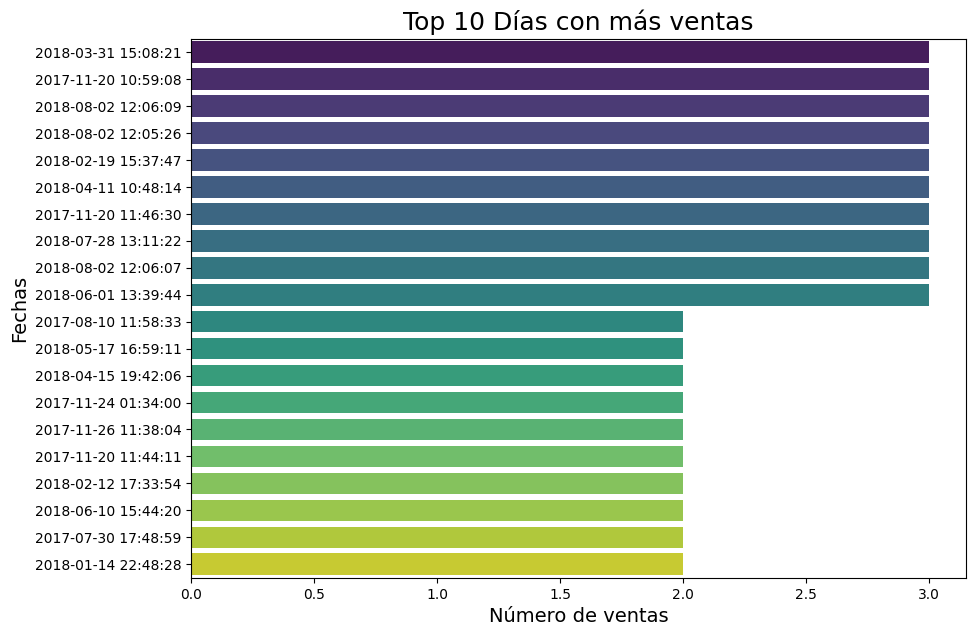

In [ ]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df_unique_order, y="order_purchase_timestamp", order=df_unique_order["order_purchase_timestamp"].value_counts().index[:20],
              palette="viridis")
plt.title("Top 10 Días con más ventas", fontsize=18)
plt.ylabel("Fechas", fontsize=14)
plt.xlabel("Número de ventas", fontsize=14)

#### Observaciones:
> - Se puede observar que la fecha con más ventas es el 2018-03-31 con más de 3 ventas. El 2018 ha producido las mejores ventas, contiene 8 de las fechas dentro del top 10. Los días con más ventas suelen ser los más próximos a la primera mitad del mes, excepto en épocas próximas a festividades donde el día con más venta está cerca del final del mes.

In [ ]:
df_unique_order["customer_unique_id"].value_counts().unique()

array([17,  9,  7,  6,  5,  4,  3,  2,  1])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22524\2649844540.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reporte, y="product_category_name_english",


Text(0.5, 0, 'Número de ventas')

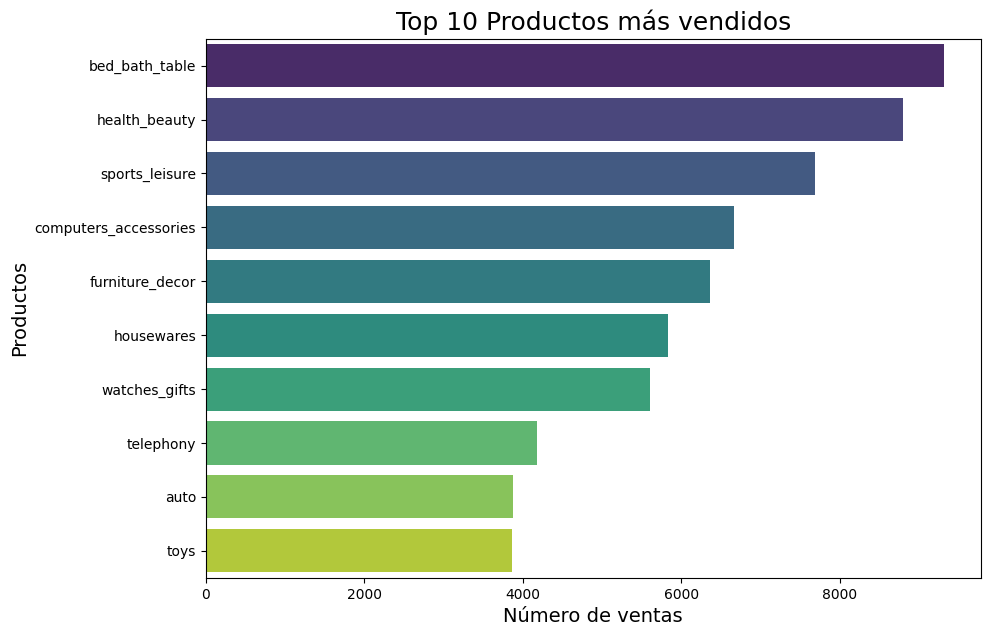

In [ ]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df_unique_order, y="product_category_name_english", 
              order=df_unique_order["product_category_name_english"].value_counts().index[:10],
              palette="viridis")
plt.title("Top 10 Productos más vendidos", fontsize=18)
plt.ylabel("Productos", fontsize=14)
plt.xlabel("Número de ventas", fontsize=14)
